# ST1504 CA2 Part B: Pendulum Control Using Reinforcement Learning

## Objective

The objective of this project is to build and evaluate a Deep Q-Network (DQN) agent capable of balancing a pendulum by applying appropriate torque.

The Pendulum environment provides the agent with three observations:

- Cosine of the pendulum angle
- Sine of the pendulum angle
- Angular velocity of the pendulum

Since the original action space is continuous, the available torque values will be discretised so that DQN can be applied.

The performance of the DQN agent will be investigated under four gravity conditions:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

In this project, the DQN agent will be trained, evaluated and systematically improved to determine a suitable setup for balancing the pendulum under the different gravity conditions.

In [59]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)

Gym version: 0.25.2
TensorFlow version: 2.10.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [60]:
env = gym.make("Pendulum-v1")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>>
Initial state: [-0.38350788  0.9235376   0.05830615]
State shape: (3,)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [61]:
env = gym.make("Pendulum-v1")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [62]:
env = gym.make("Pendulum-v1")
state = env.reset(seed=42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [63]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

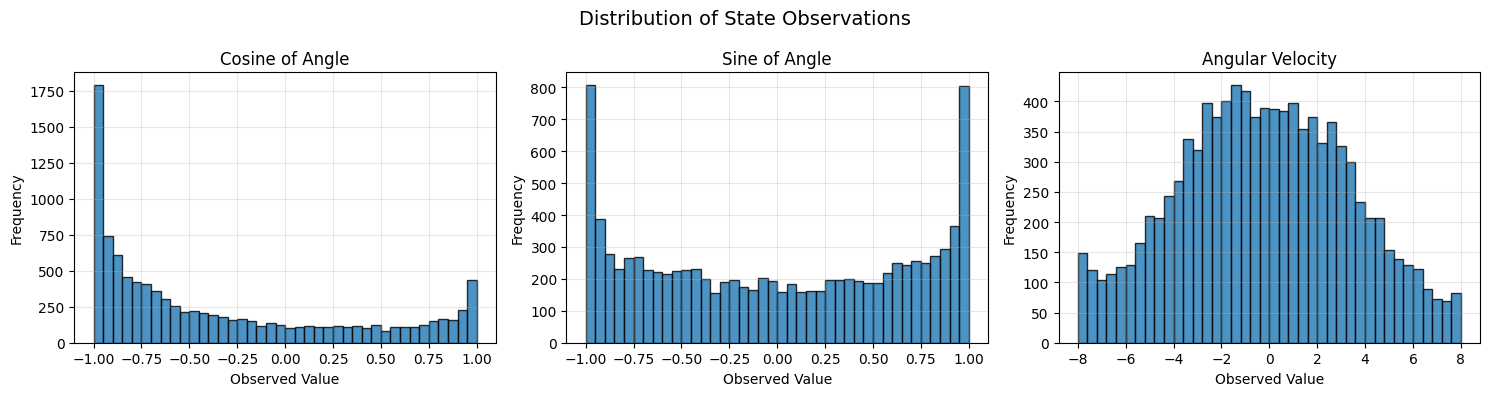

In [64]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation of State Distributions

The cosine observation is strongly concentrated near **-1**. Since a cosine value of -1 represents the pendulum pointing downwards, this shows that the random agent frequently allows the pendulum to remain near its natural hanging position. In comparison, the desired upright position has a cosine value near **1**.

The sine observation covers the complete range from -1 to 1, showing that the pendulum moves through positions on both sides of its rotation.

Angular velocity is approximately centred around zero and ranges from about -8 to 8. Its numerical range is considerably wider than the cosine and sine observations, which are limited to -1 to 1. Therefore, scaling angular velocity may help ensure that it does not have a disproportionately large influence during DQN training.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

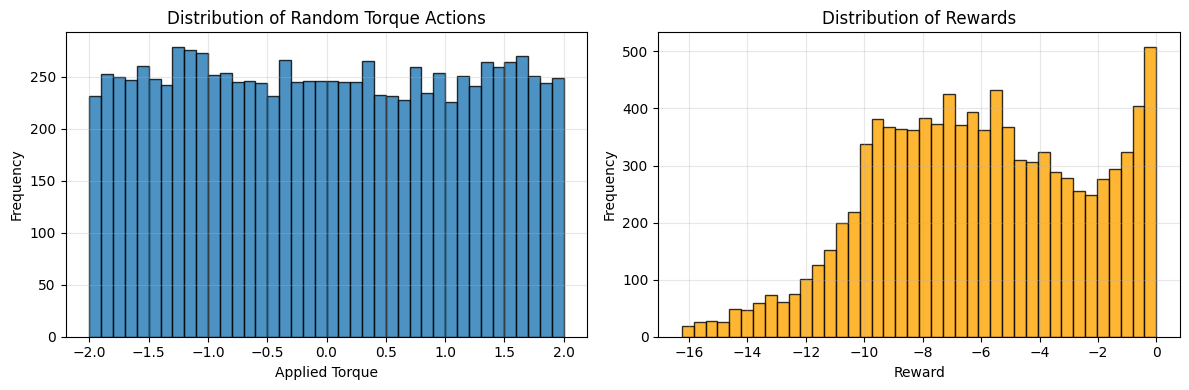

In [65]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions are distributed approximately evenly across the complete range from **-2 to 2**. This confirms that the random agent does not favour any particular torque value or direction.

The per-step rewards range from approximately **-16 to 0**, with most rewards occurring around -10 to -4. Since the maximum possible reward is zero, the mainly negative distribution indicates that the random agent generally fails to keep the pendulum upright and stable.

A smaller number of rewards appear close to zero, showing that the pendulum occasionally reaches a favourable position by chance. However, the random agent cannot maintain this position consistently because it does not learn from previous interactions.

These results provide a baseline that the trained DQN agent should improve upon by achieving rewards that are more consistently concentrated closer to zero.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [66]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


Default - Mean: -1189.63307601102 - Standard deviation: 231.64725307533595
Free-fall - Mean: -748.6178031504127 - Standard deviation: 184.61422238394752
Anti-gravity - Mean: -602.1183430727535 - Standard deviation: 396.9365950877032
Supergravity - Mean: -1386.837203404409 - Standard deviation: 124.56566538166022


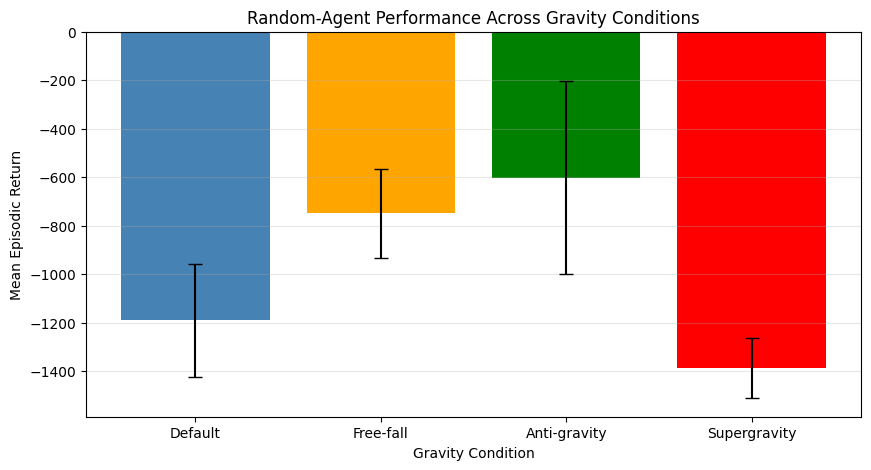

In [67]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

In [68]:
# EDA: Verify Custom Gravity Testing Compatibility
gravity_test_values = [10.0, 0.0, -10.0, 15.0]

print("Testing dynamic gravity configuration:")
for g in gravity_test_values:
    test_env = gym.make("Pendulum-v1")
    test_env.unwrapped.g = g
    test_env.reset()
    
    # Execute 1 dummy step
    _, reward, _, _ = test_env.step(test_env.action_space.sample())
    print(f"  Gravity set to {g:5.1f} | Sample Step Reward: {reward:.4f}")
    test_env.close()

Testing dynamic gravity configuration:
  Gravity set to  10.0 | Sample Step Reward: -6.2173
  Gravity set to   0.0 | Sample Step Reward: -0.1726
  Gravity set to -10.0 | Sample Step Reward: -0.4921
  Gravity set to  15.0 | Sample Step Reward: -4.2911


## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

# Observation Normalization Function

In [69]:
import numpy as np

# Preprocessing: State Observation Scaler
def normalize_state(state):
    """
    Normalize Pendulum state to approximately [-1, 1].

    State format:
        state[0] = cos(theta)  -> already in [-1, 1]
        state[1] = sin(theta)  -> already in [-1, 1]
        state[2] = theta_dot   -> expected in [-8, 8]

    Returns:
        Normalized state as float32.
    """
    state = np.asarray(state, dtype=np.float32).copy()

    # Scale angular velocity
    state[2] = np.clip(state[2] / 8.0, -1.0, 1.0)

    return state

sample_raw_state = np.array([0.5, -0.5, 6.0], dtype=np.float32)
sample_norm_state = normalize_state(sample_raw_state)

print("Raw State Sample        :", sample_raw_state)
print("Normalized State Sample :", sample_norm_state)

Raw State Sample        : [ 0.5 -0.5  6. ]
Normalized State Sample : [ 0.5  -0.5   0.75]


### Action-Space Discretisation

The original Pendulum action space contains continuous torque values ranging from -2 to 2. However, DQN can only select from a fixed number of discrete actions.

For the baseline model, the continuous range is divided into five evenly spaced torque values:

- Strong clockwise torque
- Weak clockwise torque
- No torque
- Weak counter-clockwise torque
- Strong counter-clockwise torque

Five actions provide a simple baseline while still allowing the agent to control both the direction and strength of the applied torque. Different numbers of actions can later be investigated as a systematic improvement.

In [70]:
# Action Space Discretization & Mapping Setup
import numpy as np

# Number of discrete output actions for the Deep Q-Network
number_of_actions = 5

# Dynamically fetch continuous torque bounds from the gym environment
low_torque = float(env.action_space.low[0])
high_torque = float(env.action_space.high[0])

# Generate evenly spaced discrete torque values [-2.0, -1.0, 0.0, 1.0, 2.0]
torque_values = np.linspace(
    low_torque, 
    high_torque, 
    number_of_actions,
    dtype=np.float32
)

def get_action_torque(action_index):
    """
    Maps a discrete action index (0 to 4) to the 1D NumPy array 
    format required by Gym's env.step().
    
    Handles Python ints, NumPy integers, and PyTorch tensor scalars seamlessly.
    """
    # Convert scalar tensors/numpy ints to standard Python integer
    idx = int(action_index)
    
    # Boundary check for model safety
    if idx < 0 or idx >= number_of_actions:
        raise ValueError(
            f"Action index {idx} is out of bounds! "
            f"Must be between 0 and {number_of_actions - 1}."
        )
        
    return np.array([torque_values[idx]], dtype=np.float32)


# --- Verification Tests ---
print("Discrete Action Mapping Verification:")
for action_idx in range(number_of_actions):
    continuous_torque = get_action_torque(action_idx)
    print(
        f"  Discrete Index {action_idx} ---> "
        f"Array: {continuous_torque} | "
        f"Shape: {continuous_torque.shape} | "
        f"Type: {continuous_torque.dtype}"
    )

Discrete Action Mapping Verification:
  Discrete Index 0 ---> Array: [-2.] | Shape: (1,) | Type: float32
  Discrete Index 1 ---> Array: [-1.] | Shape: (1,) | Type: float32
  Discrete Index 2 ---> Array: [0.] | Shape: (1,) | Type: float32
  Discrete Index 3 ---> Array: [1.] | Shape: (1,) | Type: float32
  Discrete Index 4 ---> Array: [2.] | Shape: (1,) | Type: float32


In [71]:
def action_index_to_torque(action_index):
    torque = torque_values[action_index]

    return np.array(
        [torque],
        dtype=np.float32
    )

In [72]:
test_action_index = 3
test_torque = action_index_to_torque(
    test_action_index
)

print("Selected action index:", test_action_index)
print("Applied torque:", test_torque)

Selected action index: 3
Applied torque: [1.]


### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: -1 to 1
- Sine of angle: -1 to 1
- Angular velocity: -8 to 8

The cosine and sine observations are already within the range of -1 to 1. However, angular velocity has a much wider range and could have a disproportionately large influence on the neural network.

Therefore, angular velocity is divided by 8 so that all three state features are approximately within the same range of -1 to 1.

The states are also converted to `float32`, which is suitable for TensorFlow model training.

In [73]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(
        state,
        dtype=np.float32
    )

    scaled_state = state / state_scale

    return np.clip(
        scaled_state,
        -1.0,
        1.0
    )

In [74]:
env = gym.make("Pendulum-v1")

original_state = env.reset()
processed_state = preprocess_state(
    original_state
)

env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)

print(
    "Processed datatype:",
    processed_state.dtype
)

Original state: [0.43378845 0.90101475 0.33155775]
Processed state: [0.43378845 0.90101475 0.04144472]
Processed datatype: float32


In [75]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print(
    "Original minimum values:",
    collected_states.min(axis=0)
)

print(
    "Original maximum values:",
    collected_states.max(axis=0)
)

print(
    "Processed minimum values:",
    processed_collected_states.min(axis=0)
)

print(
    "Processed maximum values:",
    processed_collected_states.max(axis=0)
)

Original minimum values:

 [-0.99999994 -0.9999999  -8.        ]
Original maximum values: [0.9999999 1.        8.       ]
Processed minimum values: [-0.99999994 -0.9999999  -1.        ]
Processed maximum values: [0.9999999 1.        1.       ]


### Verification of State Preprocessing

Before preprocessing, the cosine and sine observations were already within the range of -1 to 1, while angular velocity ranged from -8 to 8.

After scaling, all three observations were within approximately -1 to 1. This confirms that angular velocity was successfully scaled without changing the original meaning of the state.

Small differences from the exact limits, such as 0.9999997 instead of 1.0, are caused by floating-point precision and do not require correction.

## Modelling

### Gravity-Specific Hyperparameter Strategy

The default-gravity and supergravity environments have different dynamics. Under supergravity, the pendulum experiences a stronger downward force and may require a different action resolution, exploration schedule or learning rate.

An identical baseline configuration is first evaluated under both gravity conditions. The configuration dictionaries then allow selected hyperparameters to be tuned separately for each gravity. Final settings should be selected using mean evaluation return and performance stability rather than assuming that one setting is best for both environments.

In [76]:
# Shared baseline settings provide a fair initial comparison.
# Each dictionary can be changed independently after controlled trials.
BASELINE_CONFIGS = {
    "Default": {
        "gravity": 10.0,
        "num_actions": 5,
        "learning_rate": 0.001,
        "gamma": 0.99,
        "epsilon_decay": 0.98,
        "epsilon_min": 0.01,
        "batch_size": 64,
        "memory_size": 20000,
        "target_update_frequency": 5,
        "num_episodes": 150
    },
    "Supergravity": {
        "gravity": 15.0,
        "num_actions": 5,
        "learning_rate": 0.001,
        "gamma": 0.99,
        "epsilon_decay": 0.98,
        "epsilon_min": 0.01,
        "batch_size": 64,
        "memory_size": 20000,
        "target_update_frequency": 5,
        "num_episodes": 150
    }
}

for gravity_name, config in BASELINE_CONFIGS.items():
    print(gravity_name, config)

Default {'gravity': 10.0, 'num_actions': 5, 'learning_rate': 0.001, 'gamma': 0.99, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}
Supergravity {'gravity': 15.0, 'num_actions': 5, 'learning_rate': 0.001, 'gamma': 0.99, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}


### 1. Baseline Deep Q-Network

The baseline DQN receives the three preprocessed state observations and produces one Q-value for each discretised torque action. It uses epsilon-greedy exploration, a replay buffer and a separate target network.

The same baseline settings are used for default gravity and supergravity so that their initial learning behaviour can be compared fairly.

In [77]:
def create_env(gravity):
    return gym.make(
        "Pendulum-v1",
        g=float(gravity)
    )


def reset_environment(env, seed=None):
    result = env.reset(seed=seed) if seed is not None else env.reset()
    state = result[0] if isinstance(result, tuple) else result
    return preprocess_state(state)


def step_environment(env, action):
    result = env.step(action)

    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result

    return preprocess_state(next_state), float(reward), bool(done), info


def moving_average(values, window=10):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

In [78]:
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        gamma,
        learning_rate,
        epsilon_decay,
        epsilon_min,
        batch_size,
        memory_size
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.learning_rate = learning_rate

        self.epsilon = 1.0
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        self.batch_size = batch_size
        self.memory = deque(maxlen=memory_size)

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        model = tf.keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(self.action_dim, activation="linear")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss="mse"
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        state_tensor = tf.convert_to_tensor(
            state[None, :],
            dtype=tf.float32
        )
        q_values = self.model(state_tensor, training=False)
        return int(tf.argmax(q_values[0]).numpy())

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch = random.sample(self.memory, self.batch_size)
        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        targets = self.model(states, training=False).numpy()
        next_q_values = self.target_model(next_states, training=False).numpy()
        updated_values = rewards + (1.0 - dones) * self.gamma * np.max(next_q_values, axis=1)
        targets[np.arange(self.batch_size), actions] = updated_values

        self.model.train_on_batch(states, targets)

In [79]:
def train_agent(
    gravity_name,
    config,
    agent_class=DQNAgent,
    model_label="baseline",
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    env = create_env(config["gravity"])
    action_values = np.linspace(
        -2.0,
        2.0,
        config["num_actions"],
        dtype=np.float32
    )

    agent = agent_class(
        state_dim=env.observation_space.shape[0],
        action_dim=config["num_actions"],
        gamma=config["gamma"],
        learning_rate=config["learning_rate"],
        epsilon_decay=config["epsilon_decay"],
        epsilon_min=config["epsilon_min"],
        batch_size=config["batch_size"],
        memory_size=config["memory_size"]
    )

    episode_returns = []
    epsilon_history = []
    best_return = -np.inf

    print(
        f"\nTraining {model_label} DQN | {gravity_name} "
        f"(g={config['gravity']})"
    )

    for episode in range(1, config["num_episodes"] + 1):
        state = reset_environment(
            env,
            seed=seed + episode
        )
        done = False
        total_reward = 0.0

        while not done:
            action_index = agent.act(state)
            continuous_action = np.array(
                [action_values[action_index]],
                dtype=np.float32
            )

            next_state, reward, done, info = step_environment(
                env,
                continuous_action
            )

            agent.remember(
                state,
                action_index,
                reward,
                next_state,
                done
            )
            agent.replay()

            state = next_state
            total_reward += reward

        episode_returns.append(total_reward)
        epsilon_history.append(agent.epsilon)

        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay
        )

        if episode % config["target_update_frequency"] == 0:
            agent.update_target_network()

        if total_reward > best_return:
            best_return = total_reward
            weight_path = (
                f"best_{model_label}_"
                f"{gravity_name.lower()}.h5"
            )
            agent.model.save_weights(weight_path)

        if episode == 1 or episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{config['num_episodes']} | "
                f"Return: {total_reward:8.2f} | "
                f"Epsilon: {agent.epsilon:.3f}"
            )

    env.close()

    return {
        "agent": agent,
        "returns": np.asarray(episode_returns),
        "epsilon": np.asarray(epsilon_history),
        "best_return": best_return,
        "action_values": action_values,
        "config": config.copy()
    }

#### Baseline Training

Set `RUN_BASELINE_TRAINING` to `True` when ready. Separate agents and weight files are produced for default gravity and supergravity.

In [80]:
RUN_BASELINE_TRAINING = True
baseline_results = {}

if RUN_BASELINE_TRAINING:
    for gravity_name, config in BASELINE_CONFIGS.items():
        baseline_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=config,
            agent_class=DQNAgent,
            model_label="baseline",
            seed=42
        )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)



Training baseline DQN | Default (g=10.0)
Episode   1/150 | Return:  -861.78 | Epsilon: 0.980
Episode  10/150 | Return: -1287.45 | Epsilon: 0.817
Episode  20/150 | Return: -1279.65 | Epsilon: 0.668
Episode  30/150 | Return: -1305.64 | Epsilon: 0.545
Episode  40/150 | Return: -1214.41 | Epsilon: 0.446
Episode  50/150 | Return:  -773.23 | Epsilon: 0.364
Episode  60/150 | Return:  -516.90 | Epsilon: 0.298
Episode  70/150 | Return:  -260.18 | Epsilon: 0.243
Episode  80/150 | Return:  -513.66 | Epsilon: 0.199
Episode  90/150 | Return:  -378.00 | Epsilon: 0.162
Episode 100/150 | Return:  -350.22 | Epsilon: 0.133
Episode 110/150 | Return:  -123.42 | Epsilon: 0.108
Episode 120/150 | Return:  -233.04 | Epsilon: 0.089
Episode 130/150 | Return:  -250.00 | Epsilon: 0.072
Episode 140/150 | Return:  -247.96 | Epsilon: 0.059
Episode 150/150 | Return:  -125.90 | Epsilon: 0.048

Training baseline DQN | Supergravity (g=15.0)
Episode   1/150 | Return: -1379.19 | Epsilon: 0.980
Episode  10/150 | Return: -

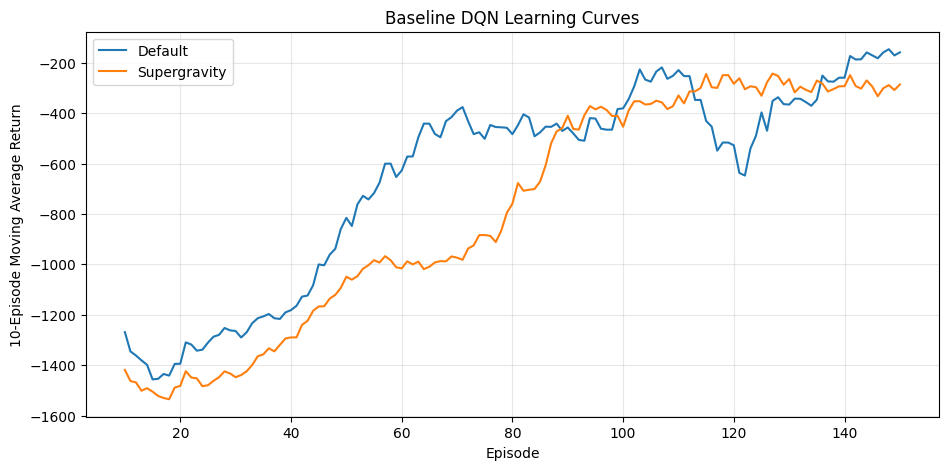

In [81]:
if baseline_results:
    plt.figure(figsize=(11, 5))

    for gravity_name, result in baseline_results.items():
        smoothed = moving_average(result["returns"], window=10)
        episodes = np.arange(10, 10 + len(smoothed))
        plt.plot(episodes, smoothed, label=gravity_name)

    plt.title("Baseline DQN Learning Curves")
    plt.xlabel("Episode")
    plt.ylabel("10-Episode Moving Average Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Run the baseline training cell first.")

### Gravity-Specific Hyperparameter Tuning

After establishing the shared baseline, tune one factor at a time for each gravity. Suitable candidates include:

- Number of discrete actions: 5, 9 or 15
- Learning rate: 0.001 or 0.0005
- Target-network update frequency: 5 or 10 episodes
- Epsilon decay: 0.98 or 0.99

The best settings may differ between default gravity and supergravity. Change only the relevant entry in `IMPROVED_CONFIGS` and record every trial so that the final choice is supported by evidence.

In [82]:
# Starting improved configurations. Update each gravity independently
# after analysing controlled tuning trials.
IMPROVED_CONFIGS = {
    "Default": {
        **BASELINE_CONFIGS["Default"],
        "num_actions": 15,
        "learning_rate": 0.0005
    },
    "Supergravity": {
        **BASELINE_CONFIGS["Supergravity"],
        "num_actions": 15,
        "learning_rate": 0.0005
    }
}

for gravity_name, config in IMPROVED_CONFIGS.items():
    print(gravity_name, config)

Default {'gravity': 10.0, 'num_actions': 15, 'learning_rate': 0.0005, 'gamma': 0.99, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}
Supergravity {'gravity': 15.0, 'num_actions': 15, 'learning_rate': 0.0005, 'gamma': 0.99, 'epsilon_decay': 0.98, 'epsilon_min': 0.01, 'batch_size': 64, 'memory_size': 20000, 'target_update_frequency': 5, 'num_episodes': 150}


## 2. Improved DQN

The improved agent combines Double DQN, a dueling network and Prioritized Experience Replay. It uses the same training function as the baseline, allowing the default and supergravity configurations to be changed independently.

In [83]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = capacity
        self.alpha = alpha
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.position = 0

    def add(self, transition):
        maximum_priority = (
            self.priorities.max() if self.buffer else 1.0
        )

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.position] = transition

        self.priorities[self.position] = maximum_priority
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size, beta=0.4):
        valid_priorities = self.priorities[:len(self.buffer)]
        probabilities = valid_priorities ** self.alpha
        probabilities /= probabilities.sum()

        indices = np.random.choice(
            len(self.buffer),
            batch_size,
            p=probabilities
        )
        samples = [self.buffer[index] for index in indices]

        weights = (len(self.buffer) * probabilities[indices]) ** (-beta)
        weights /= weights.max()

        return samples, indices, weights.astype(np.float32)

    def update_priorities(self, indices, priorities):
        for index, priority in zip(indices, priorities):
            self.priorities[index] = float(priority) + 1e-5

    def __len__(self):
        return len(self.buffer)

In [84]:
class ImprovedDQNAgent(DQNAgent):
    def __init__(self, *args, **kwargs):
        memory_size = kwargs["memory_size"]
        super().__init__(*args, **kwargs)
        self.memory = PrioritizedReplayBuffer(memory_size, alpha=0.6)
        self.beta = 0.4

    def _build_model(self):
        inputs = layers.Input(shape=(self.state_dim,))
        features = layers.Dense(128, activation="relu")(inputs)
        features = layers.Dense(128, activation="relu")(features)

        state_value = layers.Dense(64, activation="relu")(features)
        state_value = layers.Dense(1)(state_value)

        advantages = layers.Dense(64, activation="relu")(features)
        advantages = layers.Dense(self.action_dim)(advantages)

        centred_advantages = layers.Lambda(
            lambda values: values - tf.reduce_mean(
                values, axis=1, keepdims=True
            )
        )(advantages)

        outputs = layers.Lambda(
            lambda tensors: tensors[0] + tensors[1]
        )([state_value, centred_advantages])
        model = tf.keras.Model(inputs=inputs, outputs=outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss=tf.keras.losses.Huber()
        )
        return model

    def remember(self, state, action, reward, next_state, done):
        self.memory.add((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        minibatch, indices, weights = self.memory.sample(
            self.batch_size,
            beta=self.beta
        )

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        targets = self.model(states, training=False).numpy()
        previous_values = targets[np.arange(self.batch_size), actions].copy()

        online_next_q = self.model(next_states, training=False).numpy()
        best_next_actions = np.argmax(online_next_q, axis=1)
        target_next_q = self.target_model(next_states, training=False).numpy()
        selected_next_q = target_next_q[
            np.arange(self.batch_size),
            best_next_actions
        ]

        updated_values = rewards + (1.0 - dones) * self.gamma * selected_next_q
        targets[np.arange(self.batch_size), actions] = updated_values

        td_errors = np.abs(updated_values - previous_values)
        self.memory.update_priorities(indices, td_errors)
        self.model.train_on_batch(states, targets, sample_weight=weights)

#### Improved-DQN Training

Set `RUN_IMPROVED_TRAINING` to `True` only after the gravity-specific configurations have been chosen.

In [87]:
RUN_IMPROVED_TRAINING = True
improved_results = {}

if RUN_IMPROVED_TRAINING:
    for gravity_name, config in IMPROVED_CONFIGS.items():
        improved_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=config,
            agent_class=ImprovedDQNAgent,
            model_label="improved",
            seed=42
        )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)



Training improved DQN | Default (g=10.0)
Episode   1/150 | Return:  -889.38 | Epsilon: 0.980
Episode  10/150 | Return: -1156.03 | Epsilon: 0.817
Episode  20/150 | Return: -1390.42 | Epsilon: 0.668
Episode  30/150 | Return: -1308.47 | Epsilon: 0.545
Episode  40/150 | Return: -1419.72 | Epsilon: 0.446
Episode  50/150 | Return:  -128.65 | Epsilon: 0.364
Episode  60/150 | Return:  -641.13 | Epsilon: 0.298
Episode  70/150 | Return:  -395.84 | Epsilon: 0.243
Episode  80/150 | Return:  -256.31 | Epsilon: 0.199
Episode  90/150 | Return:  -376.94 | Epsilon: 0.162
Episode 100/150 | Return:  -581.67 | Epsilon: 0.133
Episode 110/150 | Return:  -483.13 | Epsilon: 0.108
Episode 120/150 | Return:  -358.27 | Epsilon: 0.089
Episode 130/150 | Return:  -381.27 | Epsilon: 0.072
Episode 140/150 | Return:  -378.34 | Epsilon: 0.059
Episode 150/150 | Return:  -138.88 | Epsilon: 0.048

Training improved DQN | Supergravity (g=15.0)
Episode   1/150 | Return: -1345.28 | Epsilon: 0.980
Episode  10/150 | Return: -

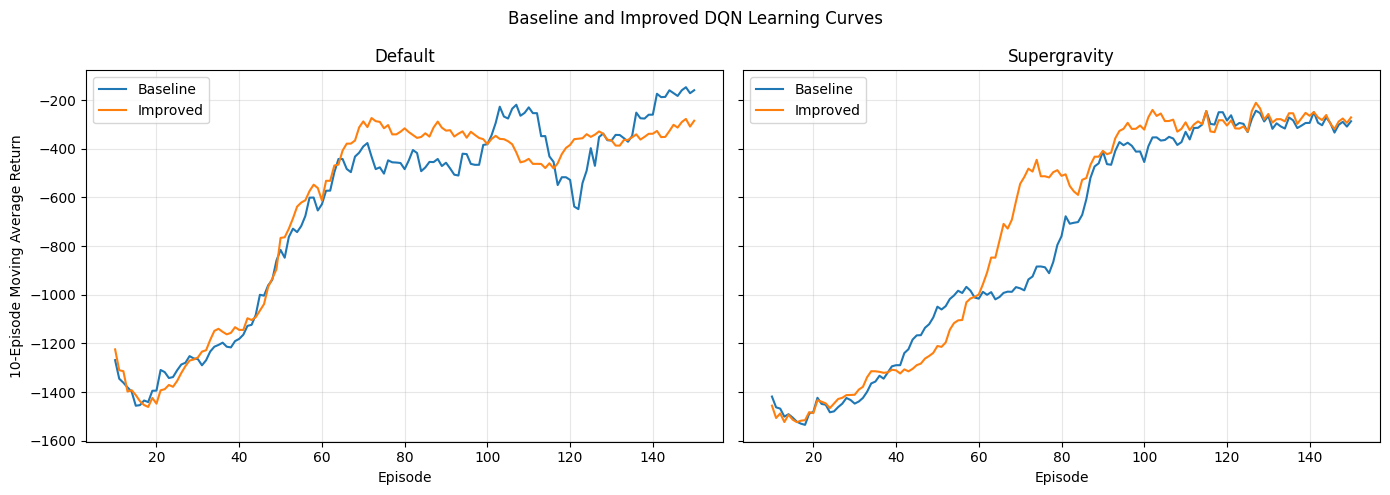

In [88]:
if baseline_results and improved_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for axis, gravity_name in zip(axes, BASELINE_CONFIGS):
        baseline_curve = moving_average(
            baseline_results[gravity_name]["returns"],
            window=10
        )
        improved_curve = moving_average(
            improved_results[gravity_name]["returns"],
            window=10
        )

        axis.plot(
            np.arange(10, 10 + len(baseline_curve)),
            baseline_curve,
            label="Baseline"
        )
        axis.plot(
            np.arange(10, 10 + len(improved_curve)),
            improved_curve,
            label="Improved"
        )

        axis.set_title(gravity_name)
        axis.set_xlabel("Episode")
        axis.grid(alpha=0.3)
        axis.legend()

    axes[0].set_ylabel("10-Episode Moving Average Return")
    plt.suptitle("Baseline and Improved DQN Learning Curves")
    plt.tight_layout()
    plt.show()
else:
    print("Train both baseline and improved agents before comparison.")

### Interpretation of Baseline and Improved Learning Curves

Under default gravity, the improved DQN initially learned faster than the baseline and achieved stronger returns during the middle of training. However, the baseline eventually surpassed the improved model and finished with a higher moving-average return. This indicates that the current improved-model hyperparameters are not yet optimal for default gravity.

Under supergravity, the improved DQN demonstrated faster learning and reached stronger returns earlier than the baseline. Both models eventually converged to a similar performance level. Therefore, the main advantage of the improved model under supergravity was faster convergence rather than a clearly higher final return.

These results show that the effects of the DQN improvements depend on the gravity condition. Separate hyperparameter configurations may therefore be required for default gravity and supergravity.

## Final Agent Evaluation

Training returns contain exploratory actions selected by the epsilon-greedy policy. Therefore, training curves alone are insufficient for selecting the best agent.

During final evaluation:

- Epsilon is set to zero so that the agent always selects its best predicted action.
- Network weights are not updated.
- No experiences are added to the replay buffer.
- Every agent is tested using the same 30 starting seeds.
- Mean, median and standard deviation of episodic returns are calculated.

A higher mean return closer to zero indicates better performance, while a lower standard deviation indicates more stable performance.

In [89]:
def evaluate_agent(
    training_result,
    evaluation_seeds
):
    agent = training_result["agent"]
    config = training_result["config"]
    action_values = training_result[
        "action_values"
    ]

    env = create_env(
        config["gravity"]
    )

    original_epsilon = agent.epsilon
    agent.epsilon = 0.0

    evaluation_returns = []

    try:
        for seed in evaluation_seeds:
            state = reset_environment(
                env,
                seed=int(seed)
            )

            done = False
            total_reward = 0.0

            while not done:
                action_index = agent.act(state)

                continuous_action = np.array(
                    [action_values[action_index]],
                    dtype=np.float32
                )

                state, reward, done, info = (
                    step_environment(
                        env,
                        continuous_action
                    )
                )

                total_reward += reward

            evaluation_returns.append(
                total_reward
            )

    finally:
        agent.epsilon = original_epsilon
        env.close()

    return np.asarray(
        evaluation_returns,
        dtype=np.float32
    )

In [90]:
evaluation_seeds = np.arange(
    1000,
    1030
)

evaluation_results = {}

for gravity_name in [
    "Default",
    "Supergravity"
]:
    evaluation_results[
        (gravity_name, "Baseline")
    ] = evaluate_agent(
        baseline_results[gravity_name],
        evaluation_seeds
    )

    evaluation_results[
        (gravity_name, "Improved")
    ] = evaluate_agent(
        improved_results[gravity_name],
        evaluation_seeds
    )

In [91]:
print(
    f"{'Gravity':<15}"
    f"{'Model':<12}"
    f"{'Mean':>12}"
    f"{'Median':>12}"
    f"{'Std Dev':>12}"
    f"{'Best':>12}"
    f"{'Worst':>12}"
)

print("-" * 87)

for (
    gravity_name,
    model_name
), returns in evaluation_results.items():

    print(
        f"{gravity_name:<15}"
        f"{model_name:<12}"
        f"{returns.mean():>12.2f}"
        f"{np.median(returns):>12.2f}"
        f"{returns.std():>12.2f}"
        f"{returns.max():>12.2f}"
        f"{returns.min():>12.2f}"
    )

Gravity        Model               Mean      Median     Std Dev        Best       Worst
---------------------------------------------------------------------------------------
Default        Baseline         -218.77     -128.46      259.23       -1.05    -1492.42
Default        Improved         -174.17     -135.24      108.00      -15.33     -445.84
Supergravity   Baseline         -363.57     -222.16      451.15       -1.00    -1655.88
Supergravity   Improved         -216.60     -221.13      120.67       -1.73     -515.90


C:\Users\kayde\AppData\Local\Temp\ipykernel_35604\1523504648.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\kayde\AppData\Local\Temp\ipykernel_35604\1523504648.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


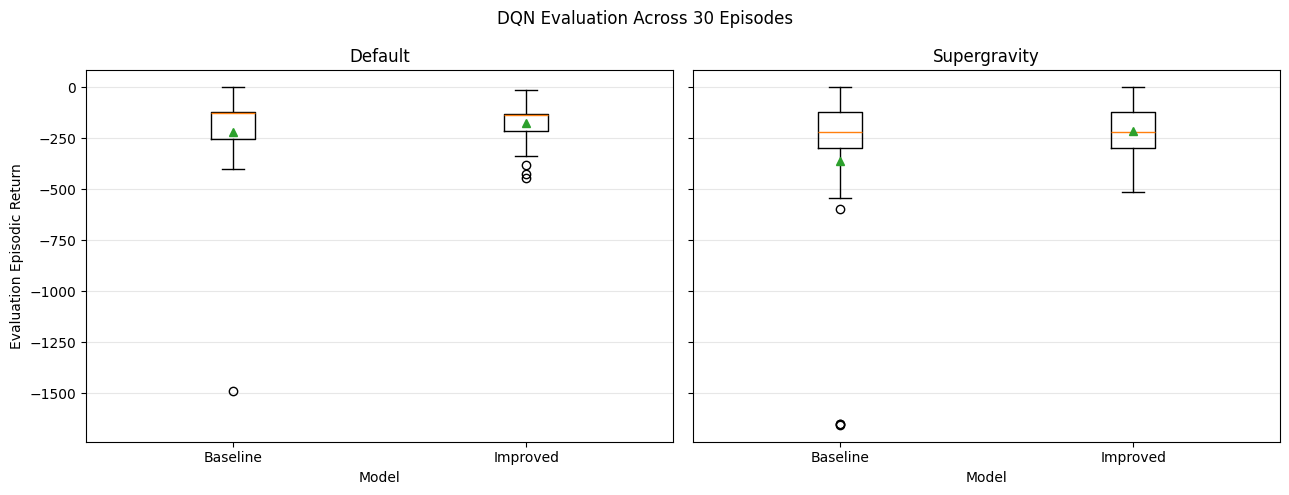

In [92]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    sharey=True
)

for axis, gravity_name in zip(
    axes,
    ["Default", "Supergravity"]
):
    baseline_returns = evaluation_results[
        (gravity_name, "Baseline")
    ]

    improved_returns = evaluation_results[
        (gravity_name, "Improved")
    ]

    axis.boxplot(
        [
            baseline_returns,
            improved_returns
        ],
        labels=[
            "Baseline",
            "Improved"
        ],
        showmeans=True
    )

    axis.set_title(gravity_name)
    axis.set_xlabel("Model")
    axis.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Evaluation Episodic Return")

plt.suptitle(
    "DQN Evaluation Across 30 Episodes"
)

plt.tight_layout()
plt.show()

## Final DQN Selection

The Improved DQN was selected as the final model for comparison with the other group members’ DQN agents. This model combines Double Deep Q-Network, Dueling Network Architecture and Prioritized Experience Replay.

Under default gravity, the Improved DQN achieved a higher mean evaluation return of **-174.17**, compared with **-218.77** for the baseline. It also reduced the standard deviation from **259.23** to **108.00**.

Under supergravity, the Improved DQN achieved a mean return of **-216.60**, compared with **-363.57** for the baseline. Its standard deviation decreased from **451.15** to **120.67**.

Between the two gravity conditions, the Improved DQN performed better under **default gravity**. Its mean return was closer to zero, its median return was higher, and its results were slightly more stable than under supergravity. This suggests that the stronger gravitational force in supergravity made balancing the pendulum more difficult.

However, the improvement over the baseline was greater under supergravity. This indicates that the enhanced DQN components were particularly useful in reducing unstable and catastrophic outcomes in the more difficult environment.

Overall, the Improved DQN was selected because it achieved better average performance and substantially greater stability across both assigned gravity conditions.
